In [3]:
import pandas as pd

df = pd.read_csv("store_customers.csv")

In [4]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
5,1005,M,33.0,36.7,73.0
6,1006,F,48.0,90.4,34.0
7,1007,F,41.0,74.8,35.0
8,1008,F,31.0,42.3,43.0
9,1009,M,39.0,48.6,61.0


In [5]:
df.shape

(1000, 5)

In [6]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [7]:
df.info

<bound method DataFrame.info of      CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0          1000      M  39.0                59.9                    58.0
1          1001      M  34.0                48.4                    37.0
2          1002      F  40.0                70.5                    26.0
3          1003      F  47.0                81.1                    30.0
4          1004      F  33.0                42.1                    58.0
..          ...    ...   ...                 ...                     ...
995        1995      M  80.0               133.3                     1.0
996        1996      M  44.0                82.6                    40.0
997        1997      F  46.0                67.7                    26.0
998        1998      F  28.0                45.7                    59.0
999        1999      M  67.0               107.8                     1.0

[1000 rows x 5 columns]>

In [8]:
df.describe

<bound method NDFrame.describe of      CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0          1000      M  39.0                59.9                    58.0
1          1001      M  34.0                48.4                    37.0
2          1002      F  40.0                70.5                    26.0
3          1003      F  47.0                81.1                    30.0
4          1004      F  33.0                42.1                    58.0
..          ...    ...   ...                 ...                     ...
995        1995      M  80.0               133.3                     1.0
996        1996      M  44.0                82.6                    40.0
997        1997      F  46.0                67.7                    26.0
998        1998      F  28.0                45.7                    59.0
999        1999      M  67.0               107.8                     1.0

[1000 rows x 5 columns]>

In [9]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [10]:
df["Gender"].value_counts()# its is categorical so we can't use median values intead we will use here mode (the value that come mostly in dataset)

Gender
F    522
M    475
Name: count, dtype: int64

In [11]:
df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,994.000000,996.000000,994.000000
mean,38.935614,57.149096,42.645875
std,13.399880,28.628506,20.101589
min,18.000000,15.000000,1.000000
25%,30.000000,34.975000,31.000000
50%,36.000000,49.000000,47.000000
75%,44.000000,79.400000,57.000000
max,80.000000,144.100000,92.000000


In [12]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Annual Income (k$)"] = df["Annual Income (k$)"].fillna(df["Annual Income (k$)"].median())
df["Spending Score (1-100)"] = df["Spending Score (1-100)"].fillna(df["Spending Score (1-100)"].median())

In [13]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [14]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

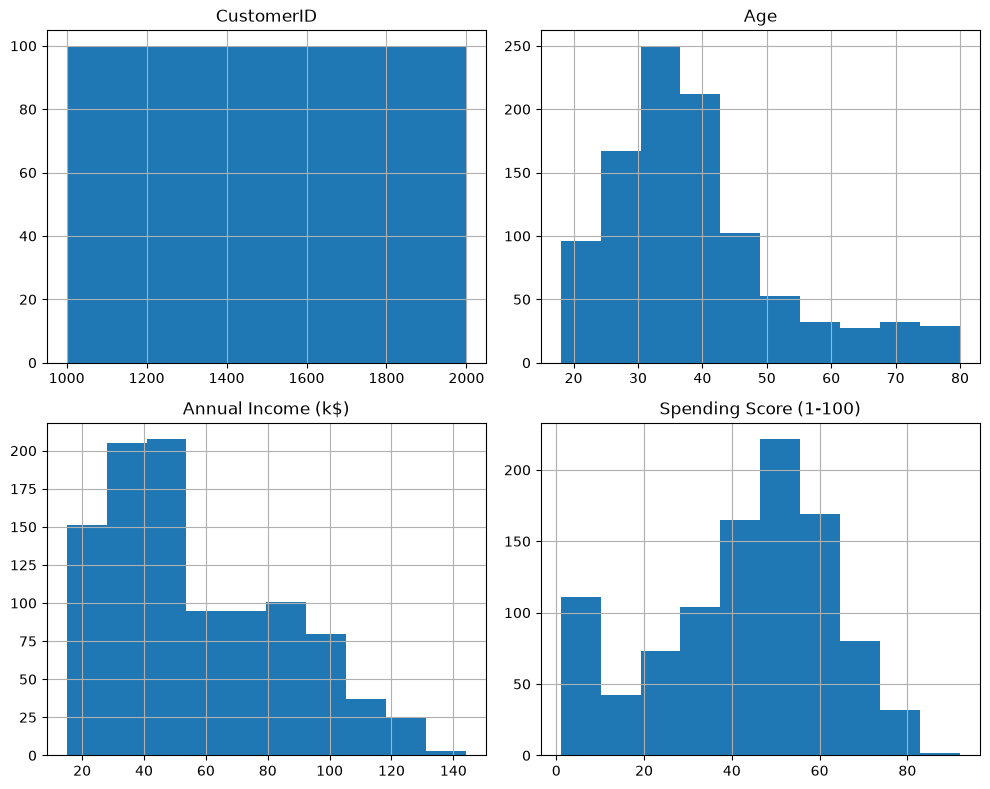

In [16]:
import matplotlib.pyplot as plt

df.hist(figsize=(10, 8))

plt.tight_layout()
plt.show()

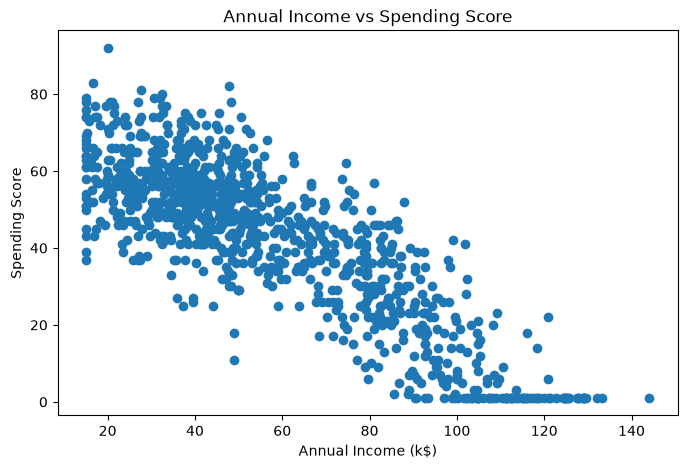

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Annual Income vs Spending Score")

plt.show()

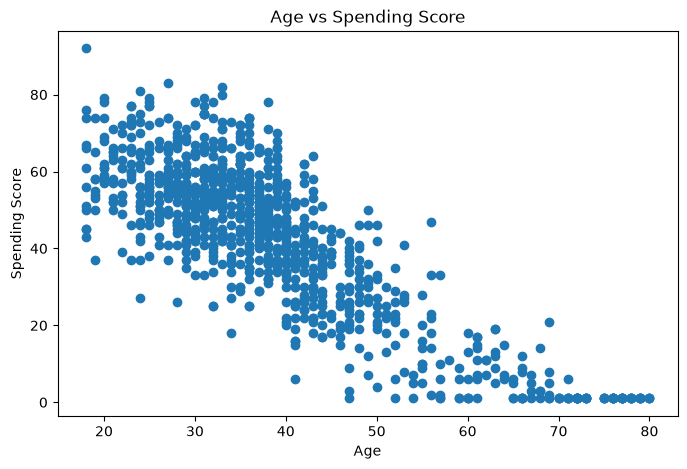

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending Score")

plt.show()

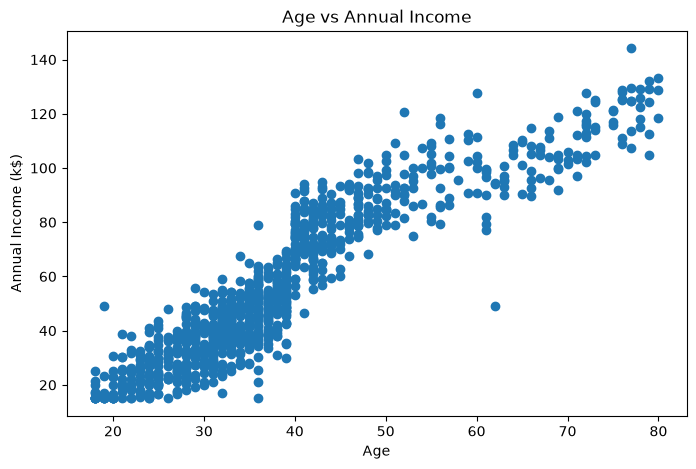

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age"],
    df["Annual Income (k$)"]
)

plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.title("Age vs Annual Income")

plt.show()

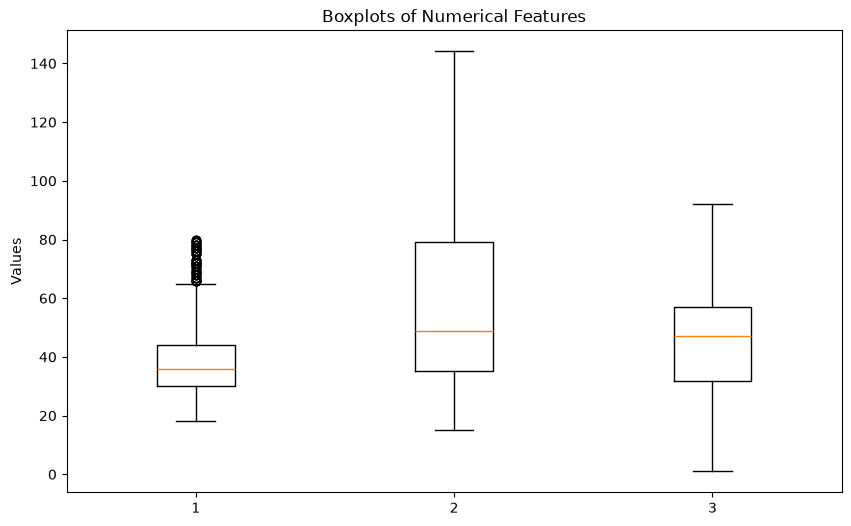

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        df["Age"],
        df["Annual Income (k$)"],
        df["Spending Score (1-100)"]
    ],
    label=[
        "Age",
        "Annual Income",
        "Spending Score"
    ]
)

plt.title("Boxplots of Numerical Features")
plt.ylabel("Values")
plt.show()

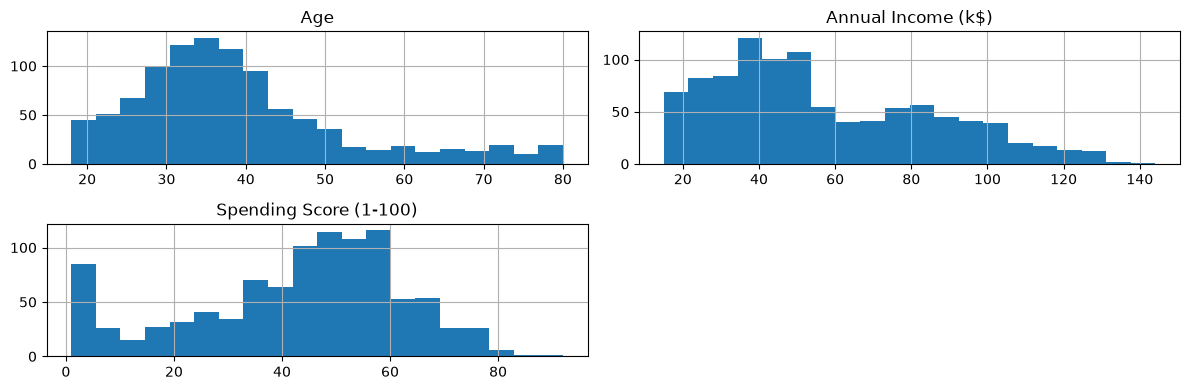

In [21]:
import matplotlib.pyplot as plt

df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].hist(
    figsize=(12, 4),
    bins=20
)

plt.tight_layout()
plt.show()

# K-Means
we use here scaling to find the difference and standard scaler to change the numerical representations of the data

In [22]:
from sklearn.preprocessing import StandardScaler

features = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

Before Scaling

In [23]:
features.head(5)

,Age,Annual Income (k$),Spending Score (1-100)
0,39.0,59.9,58.0
1,34.0,48.4,37.0
2,40.0,70.5,26.0
3,47.0,81.1,30.0
4,33.0,42.1,58.0


After Scaling

In [24]:
scaled_features

array([[ 0.0061401 ,  0.09745644,  0.76510194],
       [-0.36825649, -0.3051838 , -0.28311966],
       [ 0.08101942,  0.46858571, -0.83218813],
       ...,
       [ 0.53029534,  0.37055156, -0.83218813],
       [-0.81753241, -0.39971672,  0.81501726],
       [ 2.10276105,  1.77454057, -2.08007099]], shape=(1000, 3))

Now clusters (group of similar data points) for k means

In [25]:
from sklearn.cluster import KMeans

inertia = [] # inertia will defines that how much cluster points are far away from centriod (center of cluster)

for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state=43, n_init = 10)
    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

In [26]:
inertia

[1042.8783392950618,
 612.0161968862373,
 452.5960609741428,
 388.0754012483319,
 333.6931950676154,
 287.08027396619207,
 248.7143746453204,
 226.72019129761304,
 211.68891439682415]

# Elbow method in K-Means
we choose here elbow point neither shortest nor largest

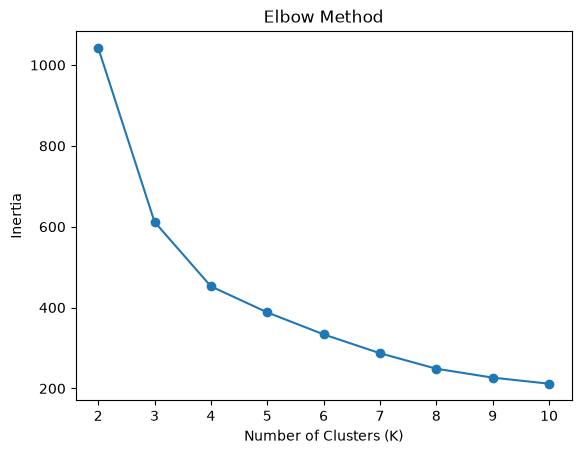

In [27]:
import matplotlib.pyplot as plt

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

# Cluster Model

In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=43,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_features)

In [29]:
print(len(clusters))

1000


In [30]:
print(clusters[:20])

[0 0 2 2 3 3 2 2 0 0 3 3 0 3 3 3 3 0 3 3]


### creating cluster dataset column

In [31]:
df["Cluster"] = clusters

In [32]:
df["Cluster"].value_counts().sort_index()

Cluster
0    330
1    128
2    210
3    332
Name: count, dtype: int64

In [33]:
cluster_summary = df.groupby("Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean()

In [34]:
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,35.642424,49.658485,47.527273
1,66.695312,107.578125,4.984375
2,45.200000,81.326190,30.295238
3,27.490964,29.761145,60.204819


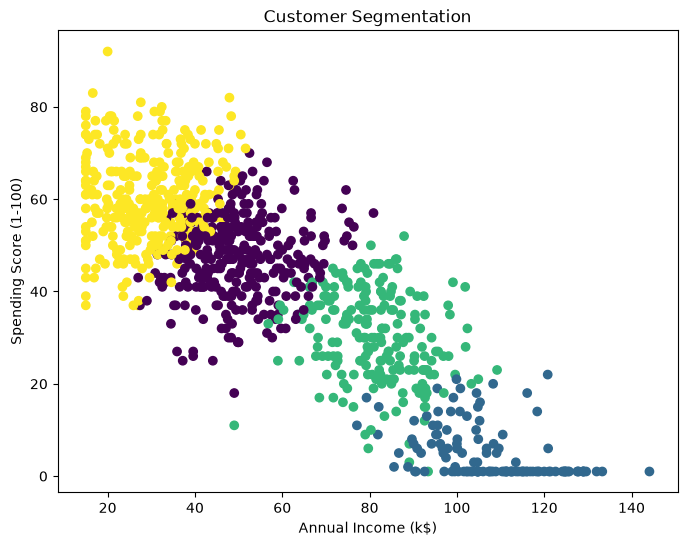

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c = df["Cluster"] # c means color
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation")

plt.show()

# Silhouette Score
how much clusters are closed and seperate from each other

close from +1 = clearly seperated


around 0 = clusters overlap


-ve = some points are wrong or nearby

In [36]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_features, df["Cluster"])
display("Silhouette Score : ", score)

'Silhouette Score : '

0.37689888156143136

Now try different value of KMeans coz it was overlapping

In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=43, n_init=10)
    labels = kmeans.fit_predict(scaled_features)

    score = silhouette_score(scaled_features, labels)

    print("K =", k, "Silhouette Score =", score)

K = 2 Silhouette Score = 0.5707449954747112
K = 3 Silhouette Score = 0.48220721004925166
K = 4 Silhouette Score = 0.37689888156143136
K = 5 Silhouette Score = 0.326916847616753
K = 6 Silhouette Score = 0.31464772550905673
K = 7 Silhouette Score = 0.3180776498035623


# Hirarchical Clustring
we merged customers in groups and make a tree like structure

## Agglomerative Clustring

In [38]:
from sklearn.cluster import AgglomerativeClustering

agg_model = AgglomerativeClustering(
    n_clusters = 3,
    linkage = "ward"
)

labels = agg_model.fit_predict(scaled_features)

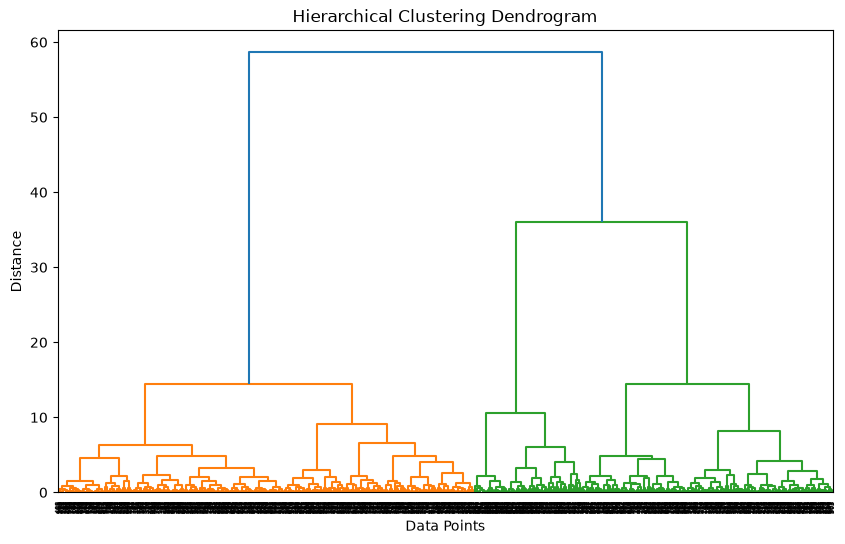

In [39]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(scaled_features, method = "ward")

plt.figure(figsize=(10, 6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [40]:
agg_model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels = agg_model.fit_predict(scaled_features)

In [41]:
print(labels)

[1 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1 1 0 1 1
 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 0 0 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 2 1 0
 1 1 0 0 1 1 0 1 0 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1
 0 1 2 1 1 1 1 0 0 2 1 0 1 0 2 1 1 1 1 1 0 1 1 1 0 1 0 0 1 0 0 1 0 1 0 1 0
 0 1 0 0 1 1 0 1 0 1 1 0 1 0 0 1 0 0 0 0 1 1 1 1 0 0 1 0 1 0 1 2 0 1 1 1 1
 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 1 2 0 0 0 0 0 0 1 1 1 1 2 1
 1 1 1 0 1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 1 0 0 1 0 1 1 0 0 1 0 0 0 1 1 0 1 1
 0 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 0 1 1 1 1 1 0 0 1 0 1 0 0 0 1 1 1 1 0 0 1
 0 0 0 0 1 1 0 0 1 1 0 1 0 1 1 0 0 0 0 0 0 1 1 0 1 0 1 2 1 1 0 0 0 0 1 1 1
 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 1 0 1
 1 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 0 0 0 0 1 1 1 0 0 1 1 0 0 0 1 1 1 1 0 0 1
 1 1 0 0 1 1 0 1 1 0 0 0 1 0 2 1 0 0 0 1 0 0 1 1 1 1 0 0 1 0 1 1 1 0 1 1 1
 1 0 0 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1 2 0 1 0 1 2 0 0
 1 1 1 1 1 1 1 0 0 1 0 0 

In [42]:
df["Cluster"] = labels

cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)","Spending Score (1-100)"]].mean()

print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        41.953560           71.994118               35.291022
1        30.275093           35.677323               56.754647
2        65.316547          105.525180                5.316547


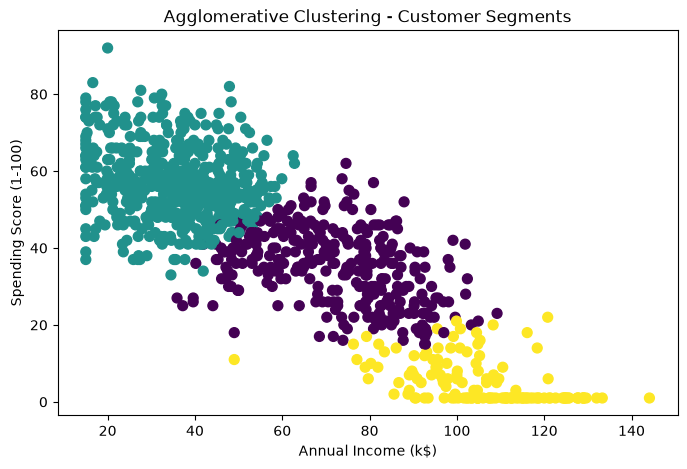

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=50
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Agglomerative Clustering - Customer Segments")
plt.show()

In [44]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_features, labels)

print("Agglomerative Clustering Silhouette Score:", score)

Agglomerative Clustering Silhouette Score: 0.4663322682569328


In [45]:
# Silhouette Scores
kmeans_score = 0.37689888156143136
agglomerative_score = 0.4663322682569328

# Comparison
models = ["K-Means (K=4)", "Agglomerative (K=3)"]
scores = [kmeans_score, agglomerative_score]

comparison = pd.DataFrame({
    "Clustering Method": models,
    "Silhouette Score": scores
})

print(comparison)
# Best model
if agglomerative_score > kmeans_score:
    print("\nBetter Clustering Method: Agglomerative Clustering")
else:
    print("\nBetter Clustering Method: K-Means")

     Clustering Method  Silhouette Score
0        K-Means (K=4)          0.376899
1  Agglomerative (K=3)          0.466332

Better Clustering Method: Agglomerative Clustering


In [46]:
cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        41.953560           71.994118               35.291022
1        30.275093           35.677323               56.754647
2        65.316547          105.525180                5.316547


In [47]:
customer_summary = {
    0: "Moderate Customer",
    1: "High-Spending Customer",
    2: "Low-Spending Customer"
}

In [48]:
from scipy.spatial.distance import cdist

# 1. Train Agglomerative Clustering model
agg_model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

agg_labels = agg_model.fit_predict(scaled_features)

# 2. Save Agglomerative cluster labels
df["Agg_Cluster"] = agg_labels

# 3. New customer
new_customer = [[25, 66, 99]]

# 4. Scale new customer
new_customer_scaled = scaler.transform(new_customer)

# 5. Get centers of the Agglomerative clusters
cluster_centers = df.groupby("Agg_Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean()

# 6. Scale the cluster centers
cluster_centers_scaled = scaler.transform(cluster_centers)

# 7. Calculate distance from new customer to each cluster center
distances = cdist(
    new_customer_scaled,
    cluster_centers_scaled
)

# 8. Assign new customer to nearest cluster
new_customer_cluster = distances.argmin(axis=1)[0]

print("New Customer:", new_customer)
print("Assigned Cluster:", new_customer_cluster)

New Customer: [[25, 66, 99]]
Assigned Cluster: 1


c:\Users\DELL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [49]:
cluster_summary = {
    0: "Moderate Customer",
    1: "High Income, Low Spending Customer",
    2: "High Income, Moderate Spending Customer"
}

customer_type = cluster_summary[new_customer_cluster]

print("Cluster:", new_customer_cluster)
print("Customer Type:", customer_type)

Cluster: 1
Customer Type: High Income, Low Spending Customer


In [50]:
import time
import numpy as np
import pandas as pd
import ipywidgets as w
from IPython.display import display

feats = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
colors = ["#227aee", "#a78bfa", "#f472b6", "#fbbf24", "#34d399", "#fb7185"]

overall = df[feats].mean()
sizes = df["Cluster"].value_counts().sort_index()
profile = df.groupby("Cluster")[feats].mean().round(0)
centers = pd.DataFrame(scaled_features).groupby(df["Cluster"].values).mean()


def seg_label(r):
    inc = "High income" if r[feats[1]] > overall[feats[1]] else "Low income"
    sp = "High spending" if r[feats[2]] > overall[feats[2]] else "Low spending"
    return f"{inc} / {sp}"


clusters = []
for i in profile.index:
    r = profile.loc[i]
    clusters.append(dict(
        id=int(i), label=seg_label(r), size=int(sizes[i]),
        pct=round(100 * sizes[i] / len(df)),
        age=int(r[feats[0]]), income=int(r[feats[1]]), spend=int(r[feats[2]]),
        center=centers.loc[i].to_numpy(),
    ))

CSS = """
<style>
  .cs-card{font-family:'Segoe UI',Roboto,Arial,sans-serif;color:#e2e8f0;border-radius:22px;padding:28px 32px;
    background:linear-gradient(135deg,#0f172a 0%,#1e1b4b 55%,#312e81 100%);box-shadow:0 14px 40px rgba(0,0,0,.4)}
  .cs-badge{display:inline-block;padding:6px 14px;border-radius:999px;font-size:13px;letter-spacing:.5px;
    background:rgba(34,211,238,.15);color:#22d3ee;border:1px solid rgba(34,211,238,.4);animation:cs-up .7s ease both}
  .cs-title{font-size:34px;font-weight:800;line-height:1.15;margin:14px 0 6px;
    background:linear-gradient(90deg,#22d3ee,#a78bfa,#f472b6);-webkit-background-clip:text;background-clip:text;
    color:transparent;animation:cs-up .8s ease .15s both}
  .cs-sub{color:#94a3b8;font-size:16px;margin-bottom:14px;animation:cs-up .8s ease .3s both}
  .cs-chips span{display:inline-block;margin:0 8px 8px 0;padding:5px 12px;border-radius:999px;font-size:12.5px;
    background:rgba(255,255,255,.07);border:1px solid rgba(255,255,255,.12);color:#cbd5e1}
  .cs-res{animation:cs-pop .6s ease both;border:1px solid var(--c)}
  .cs-res small{color:#94a3b8;text-transform:uppercase;letter-spacing:1px;font-size:12px}
  .cs-res h2{margin:6px 0 4px;font-size:30px;color:var(--c);font-weight:800}
  .cs-res p{margin:0 0 14px;color:#cbd5e1;font-size:15px}
  .cs-cmp div{display:inline-block;margin:0 10px 8px 0;min-width:150px;padding:10px 12px;border-radius:12px;
    background:rgba(0,0,0,.28);font-size:13px;color:#94a3b8}
  .cs-cmp b{display:block;color:#fff;font-size:16px;margin-top:2px}
  .cs-grid{display:flex;gap:12px;flex-wrap:wrap}
  .cs-cluster{flex:1;min-width:170px;padding:14px;border-radius:16px;border-top:4px solid var(--c);
    background:rgba(255,255,255,.07);opacity:.45}
  .cs-cluster.active{opacity:1;background:rgba(255,255,255,.16);box-shadow:0 10px 30px rgba(0,0,0,.45)}
  .cs-ctitle{font-weight:700;color:var(--c);font-size:16px}
  .cs-csize{font-size:12px;color:#94a3b8;margin-bottom:6px}
  .cs-cstat{display:flex;justify-content:space-between;font-size:13.5px;padding:2px 0}
  .cs-cstat span{color:#94a3b8}
  .cs-err{color:#fb7185;font-size:14px;font-family:'Segoe UI',Arial,sans-serif}
  @keyframes cs-up{from{opacity:0;transform:translateY(18px)}to{opacity:1;transform:none}}
  @keyframes cs-pop{from{opacity:0;transform:scale(.92)}to{opacity:1;transform:scale(1)}}
</style>
"""

header = w.HTML(CSS + """
<div class="cs-card">
  <span class="cs-badge">MACHINE LEARNING PROJECT</span>
  <div class="cs-title">Customer Segmentation<br>using Clustering</div>
  <div class="cs-sub">Enter a customer's details and find out which segment they belong to</div>
  <div class="cs-chips"><span>Data Cleaning</span><span>EDA</span><span>StandardScaler</span>
    <span>K-Means</span><span>Elbow + Silhouette</span><span>Hierarchical</span></div>
</div>""")

box_style = {"description_width": "initial"}
age_in = w.Text(description="Age", placeholder="e.g. 28", style=box_style, layout=w.Layout(width="190px"))
inc_in = w.Text(description="Annual Income (k$)", placeholder="e.g. 60", style=box_style, layout=w.Layout(width="260px"))
sp_in = w.Text(description="Spending Score (1-100)", placeholder="e.g. 75", style=box_style, layout=w.Layout(width="290px"))
btn = w.Button(description="Find Segment", button_style="primary", layout=w.Layout(width="160px", height="34px"))
form = w.HBox([age_in, inc_in, sp_in, btn], layout=w.Layout(flex_flow="row wrap", margin="12px 0 4px 0"))

msg = w.HTML("")
result = w.HTML("")


def cards_html(active=None):
    out = '<div class="cs-grid">'
    for i, c in enumerate(clusters):
        cls = "cs-cluster active" if i == active else "cs-cluster"
        out += (f'<div class="{cls}" style="--c:{colors[i % len(colors)]}">'
                f'<div class="cs-ctitle">Cluster {c["id"]}</div>'
                f'<div class="cs-csize">{c["size"]} customers ({c["pct"]}%)</div>'
                f'<div class="cs-cstat"><span>Avg age</span><b>{c["age"]}</b></div>'
                f'<div class="cs-cstat"><span>Avg income</span><b>{c["income"]}k$</b></div>'
                f'<div class="cs-cstat"><span>Avg spending</span><b>{c["spend"]}</b></div></div>')
    return out + "</div>"


cards = w.HTML(CSS + cards_html())


def on_click(_):
    result.value = ""
    try:
        a, inc, sp = float(age_in.value), float(inc_in.value), float(sp_in.value)
        assert 10 <= a <= 100 and 0 <= inc <= 400 and 1 <= sp <= 100
    except Exception:
        msg.value = ('<div class="cs-err">Please fill all 3 fields with valid numbers '
                     '(Age 10-100, Income 0-400, Spending 1-100).</div>')
        return
    msg.value = ""
    btn.disabled = True
    btn.description = "Analyzing..."
    time.sleep(0.7)

    x = (np.array([a, inc, sp]) - scaler.mean_) / scaler.scale_
    best = int(np.argmin([np.sum((c["center"] - x) ** 2) for c in clusters]))
    c, col = clusters[best], colors[best % len(colors)]

    result.value = CSS + f"""
    <div class="cs-card cs-res" style="--c:{col}">
      <small>Predicted segment</small>
      <h2>Cluster {c['id']}</h2>
      <p>{c['label']} &nbsp;|&nbsp; {c['pct']}% of all customers</p>
      <div class="cs-cmp">
        <div>Age<b>{a:g} vs {c['age']}</b></div>
        <div>Income (k$)<b>{inc:g} vs {c['income']}</b></div>
        <div>Spending<b>{sp:g} vs {c['spend']}</b></div>
      </div>
    </div>"""
    cards.value = CSS + cards_html(best)
    btn.description = "Find Segment"
    btn.disabled = False


btn.on_click(on_click)
display(w.VBox([header, form, msg, result, cards]))